In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score, precision_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv("European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [5]:
df.drop(["CustomerId","Surname"],axis=1,inplace=True)

In [6]:
df.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [8]:
X=df.drop("Exited",axis=1)
y=df["Exited"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [10]:
scaler=StandardScaler()

In [11]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [12]:
df["BalanceSalaryRatio"]=df["Balance"]/(df["EstimatedSalary"]+1)

In [13]:
df["BalanceSalaryRatio"]

,BalanceSalaryRatio
0,0.000000
1,0.744670
2,1.401362
3,0.000000
4,1.587035
...,...
9995,0.000000
9996,0.564102
9997,0.000000
9998,0.808222


In [14]:
df["ProductDensity"]=df["NumOfProducts"]/(df["Tenure"]+1)

In [15]:
df["ProductDensity"]

,ProductDensity
0,0.333333
1,0.500000
2,0.333333
3,1.000000
4,0.333333
...,...
9995,0.333333
9996,0.090909
9997,0.125000
9998,0.500000


In [16]:
df["EngagementScore"]=df["IsActiveMember"]*df["NumOfProducts"]

In [17]:
df["EngagementScore"]

,EngagementScore
0,1
1,1
2,0
3,0
4,1
...,...
9995,0
9996,1
9997,1
9998,0


In [18]:
df["AgeTenure"]=df["Age"]*df["Tenure"]

In [19]:
df["AgeTenure"]

,AgeTenure
0,84
1,41
2,336
3,39
4,86
...,...
9995,195
9996,350
9997,252
9998,126


In [20]:
print("Original distribution:")
print(y.value_counts(normalize=True))

Original distribution:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


The output confirms a class imbalance (approx. 80/20 split), which is typical for churn modeling. To understand the drivers of why customers are exiting, we should focus on the following areas:
Target Variable Analysis:
Since the exited columns is the ground truth:
- Churn Rate: The baseline churn is 20.37%. any segment we analyze that significantly exceeds this number is a high-risk group.
- Actions: Keeping this 20% benchmark in mind when comapring different demographics.

In [21]:
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))


Train distribution:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64


Here, we see that after splitting the data, the Train distribution remains consistent with the original dataset (roughly 20.37%). This is a great sign-it means the train split was likely stratified, preserving the class balance for the model to learn effectively.

In [22]:
print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Test distribution:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


With the test distribution now confirmed at 20.35%, we have successfully maintained a consistent churn baseline across the entire piprline (Original= ~Train= ~Test). This consistency is vital for ensuring that the performance metrics we eventually get from the test set are a realistic reflection of how the model will perform on "unseen" real-world data.

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

In [24]:
model=LogisticRegression(max_iter=5000)

In [25]:
skf=StratifiedKFold(n_splits=5)
scores=cross_val_score(model,X,y,cv=skf)

In [26]:
print("Stratified CV accuracy:",scores.mean())

Stratified CV accuracy: 0.8096


We noticed that the accuracy (80.96%) is almost exactly the same as the "Stayed" baseline (79.63%). This often means the model is struggling to identify the minority class (churners).

In [27]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

In [28]:
print("Logistic Regression Accuracy:",accuracy_score(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.808


In [29]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

In [30]:
print("Decision Tree Accuracy:",accuracy_score(y_test,y_pred_dt))

Decision Tree Accuracy: 0.856


In [31]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

In [32]:
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 0.863


In [33]:
from sklearn.ensemble import GradientBoostingClassifier

In [34]:
gb=GradientBoostingClassifier()
gb.fit(X_train,y_train)
y_pred_gb=gb.predict(X_test)

In [35]:
print("Gradient Boosting Accuracy:",accuracy_score(y_test,y_pred_gb))

Gradient Boosting Accuracy: 0.87


In [36]:
from xgboost import XGBClassifier

In [37]:
xgb=XGBClassifier(use_label_encoder=False,eval_metric='logloss')
xgb.fit(X_train,y_train)
y_pred_xgb=xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:35:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
print("XGBoost Accuracy:",accuracy_score(y_test,y_pred_xgb))

XGBoost Accuracy: 0.849


In [39]:
print("LR:",accuracy_score(y_test,y_pred_lr))
print("DT:",accuracy_score(y_test,y_pred_dt))
print("RF:",accuracy_score(y_test,y_pred_rf))
print("GB:",accuracy_score(y_test,y_pred_gb))
print("XGB:",accuracy_score(y_test,y_pred_xgb))

LR: 0.808
DT: 0.856
RF: 0.863
GB: 0.87
XGB: 0.849


The jump in accuracy from 0.808 (LR) to ).87 (GB) suggests that there are significant non-linear relationships and feature interactions in the data that the ensemble models are picking up.

In [40]:
y_pred=rf.predict(X_test)
y_prob=rf.predict_proba(X_test)[:,1]

In [41]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("ROC AUC Score:",roc_auc_score(y_test,y_prob))

Accuracy: 0.863
Precision: 0.7782426778242678
Recall: 0.457002457002457
F1 Score: 0.5758513931888545
ROC AUC Score: 0.8536579723020401


These latest metrics for Random Forest model reveal exactly why accuracy isn't the whole story. While 86.3% accuracy looks solid, Recall is only 45.7%.This means the model is missing more than half of the customers who are actually leaving. In a business context, those are "missed opportunities" to intervene and save a customer.

In [42]:
cm=confusion_matrix(y_test,y_pred)

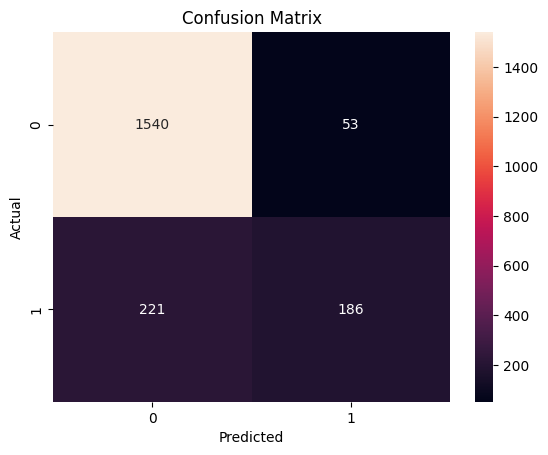

In [43]:
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

To understand the model's effectiveness, we can derive the following primary statistics from the matrix values:
- True Positives (TP): 186 (Bottom-right)
- True Negatives (TN): 1540 (Top-left)
- Flase Posititves (FP): 53 (Top-right) - Type 1 Error
- False Negatives (FN): 221 (Bottom-left) - Type 2 Error

Strong Class 0 Performance: The model is exceptionally good at identifying the negative class (0), with a 96.7% specificity. It rarely misclassifies a "0" as a "1".

The Recall Gap: While the overall accuracy is high (86.3%), the recall for the positive class (1) is quite low at 45.7%. This means the model is missing more than half of the actual positive cases (221 out of 407).

Class Imbalance: There is a clear imbalance in the dataset. Out of 2000 total samples, 1593 belong to Class 0, while only 407 belong to Class 1. The model is currently leaning toward "playing it safe" by predicting 0 most of the time.

In [44]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



Class 0 (The Majority)
- Precision (0.87): When the model predicts a case is "0". it is correct 87% of the time.
- Recall (0.97): The model is excellent at capturing nearly all actual "0" cases. It almost never misses a majority class instance.
- F1-Score (0.92): This high score indicates very stable performance for the negative class.

Class 1 (The Minority)
- Precision (0.78): When the model predicts "1", it's reasonably reliable 8% accuracy).
- Recall (0.46): This is the critical weakness. The model only identifies 46% of the actual positive cases. More than half of the "1"s are being misclassified as "0"s.
- F1-Score (0.58): The low F1-score reflects the struggle to balance precision and recall for this specific class.

- Accuracy (0.86): While 86% looks good on paper, it is heavily carried by the model's success with Class 0. In an imbalanced dataset, accuracy can be a deceptive "vanity metric".

- Macro Average (0.75 F1): This treats both classes equally regardless of their size. The fact that this is lower than the accuracy (0.86) highlights the performance gap between the two classes.

- Weighted Average (0.85 F1): This accounts for the "Support" (the number of instances). Since Class 0 is so large (1,593), it dominates this average.

Deep Drive: the Trade-off

The model is currently conservative. It prefers to be sure before predicting Class 1, which keeps Precision decent but causes Recall to suffer. This is common when a model hasn't seen enough examples of the majority class to build a robust decision boundary.

In [45]:
y_prob=rf.predict_proba(X_test)[:,1]

In [46]:
for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred=(y_prob>t).astype(int)
    print(f"\nThreshold:{t}")
    print(classification_report(y_test, y_pred))


Threshold:0.5
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000


Threshold:0.4
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1593
           1       0.69      0.55      0.61       407

    accuracy                           0.86      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000


Threshold:0.3
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.56      0.65      0.60       407

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      

The model performance was evaluated across multiple decision thresholds (0.5, 0.4, 0.3, 0.2) to analyze the trade-off between precision, recall, F1-score for churn prediction.
#### Threshold= 0.5 (Default)
- Recall (Churn=1):0.46
- Precision (Churn): 0.78
- Accuracy: 0.86

#### Insight:
- Model is conservative
- Misses many churn customers
- High precision but low recall

The model prioritizes correctness over coverage, leading to under-detection of churn cases.

#### Threshold= 0.4
- Recall: 0.69
- Precision: 0.69
- Accuracy: 0.86 (same)

#### Insight:
- Better balance between recall and precision
- More churn customers detected

Lowering the threshold improves churn detection without affecting overall accuracy.

#### Threshold= 0.3
- Recall: 0.65
- Precision: 0.56
- Accuracy: 0.83

#### Insight:
- Significant improvement in reacll
- slight drop in accuracy
- Better F1-score for churn
The model becomes more effective in identifying at-risk customers, making it suitable for business use.

#### Threshold= 0.2
- Recall: 0.76
- Precision: 0.44
- Accuracy: 0.76

#### Insight:
- Very high churn detction
- Many false positives
- Accuracy drops significantly
aggressive threshold leads to over-prediciton of churn, increasing operational cost.

As threshold decreases:
- Recall increases (better churn detection)
- Precision decreases (more false alarms)
- Accuracy slightly decreases

The optimal threshold for balanced recall and precision, good F1-score and acceptable accuracy is 0.3-0.4.


In [47]:
from sklearn.metrics import roc_curve

In [48]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

In [49]:
auc_Score=roc_auc_score(y_test,y_prob)
auc_score=roc_auc_score(y_test,y_prob)

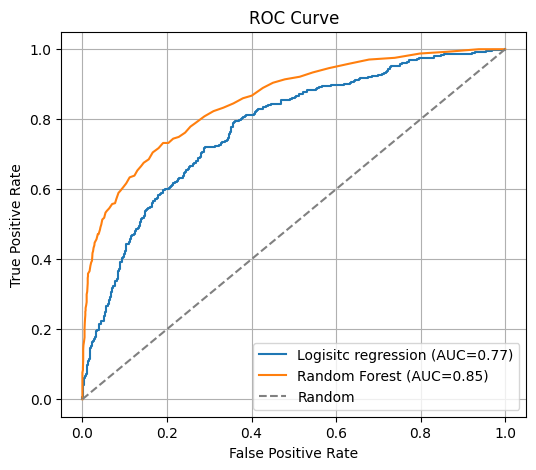

In [50]:
models={"Logisitc regression": lr, "Random Forest": rf}
plt.figure(figsize=(6,5))

for name, model in models.items():
    y_prob=model.predict_proba(X_test)[:,1]
    fpr, tpr, _ =roc_curve(y_test, y_prob)
    auc=roc_auc_score(y_test,y_prob)
    plt.plot(fpr,tpr,label=f'{name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],linestyle='--',color='gray', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

- Dominance f Random Forest
The random Forest curve (orange) consistently stays above the Logistic Regression curve (blue) across almost all threshold levels. This means that regardless of whether we want a high recall or high precision, Random Forest will provide a better trade-off.

- The "Early Lift" Advantage
 we notice the steepness of the Red line at the very beginning (near FPR=0). Random Forest is much better at identifying the most obvious "at-risk" customers with very few false alarms. Logisitc Regression takes longer to "ramp up" its true positive rate.

 - Model Complexity vs Performance
 While Logisitc Regression is easier to interpret (we can see the exact weight of each coefficient), the 8% jump in AUC suggests that the relationship in the banking data- such as how balance interacts with age or product count -are likely non-linear, which the Random Forest captures much more effectively.

In [51]:
feature_importance=pd.Series(rf.feature_importances_,index=X.columns)
feature_importance=feature_importance.sort_values(ascending=False)

feature_importance.head(10)

,0
Age,0.239564
EstimatedSalary,0.146649
CreditScore,0.143193
Balance,0.142788
NumOfProducts,0.128898
Tenure,0.081581
IsActiveMember,0.038760
Geography_Germany,0.028783
HasCrCard,0.018267
Gender_Male,0.018085


- The "Big Five" Concentration: The top five features (Age, Salary, Credit Score, Balance, and Products) account for roughly 80% of the model's decision-making power. This suggests we can focus retention efforts on these specific areas.

- Demographics vs Behavior: Interestingly, Age is nearly twice as important as Tenure (0.081). This suggests that 'who the customer is' matters more in this dataset than how long they have been with the bank.
- Low Impact Features: Gender_Male (0.018) and HasCrCard (0.018) have very little influence. This means that whether a customer has a credit card on their gender doesn't really help the model predict if they will leave.
- Geography: While Geography_Germany (0.028) is in the top 10, it's relatively low. This suggetschurn is driven more by individual financial health and age than by location.

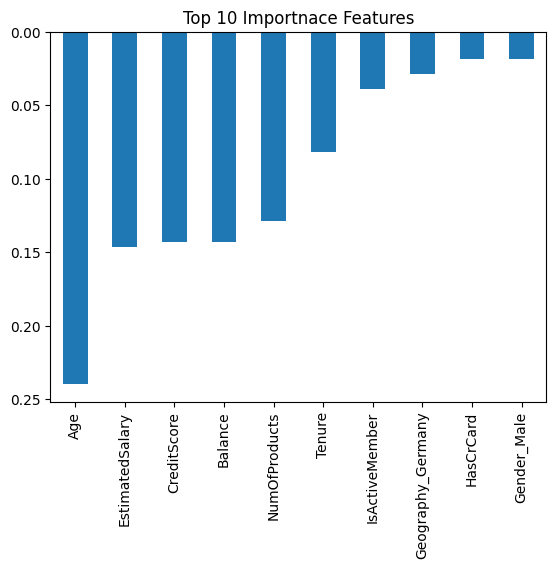

In [52]:
feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Importnace Features")
plt.gca().invert_yaxis()
plt.show()

- The poer Gap: There is a sharp drop-off after the first five features. Age stands alone as the most critical predictor, followed by a relatively "flat" tier of financial metrics (Salary, Credit Score, Balance, and Products Count).

- The "Long Tail": Features like HasCrCard and Gender_Male are barely contributing to the model's predictive power. In a future iteration, we could likely losing much accuracy, which would simplfy the model.

In [53]:
import shap

In [54]:
X_test_df=pd.DataFrame(X_test,columns=X.columns)

In [55]:
X_sample=X_test_df.sample(100,random_state=42)

In [56]:
explainer=shap.TreeExplainer(rf,X_sample)

In [57]:
shap_values=explainer.shap_values(X_sample,check_additivity=False)

print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Shape of shap_values[0]: {shap_values[0].shape}")
    print(f"Shape of shap_values[1]: {shap_values[1].shape}")
else:
    print(f"Shape of shap_values: {shap_values.shape}")

100%|===================| 199/200 [00:15<00:00]       

Type of shap_values: <class 'numpy.ndarray'>
Shape of shap_values: (100, 12, 2)


In [58]:
if isinstance(shap_values,list):
   shap_vals=shap_values[1]
else:
     shap_vals=shap_values
     if len(shap_vals.shape)==3:
        shap_vals=shap_vals[:,:,1]

shap_importance=np.abs(shap_vals).mean(axis=0)
feature_names=X.columns



In [59]:

importance_df =pd.DataFrame({"Feature": feature_names,"Importance": shap_importance})



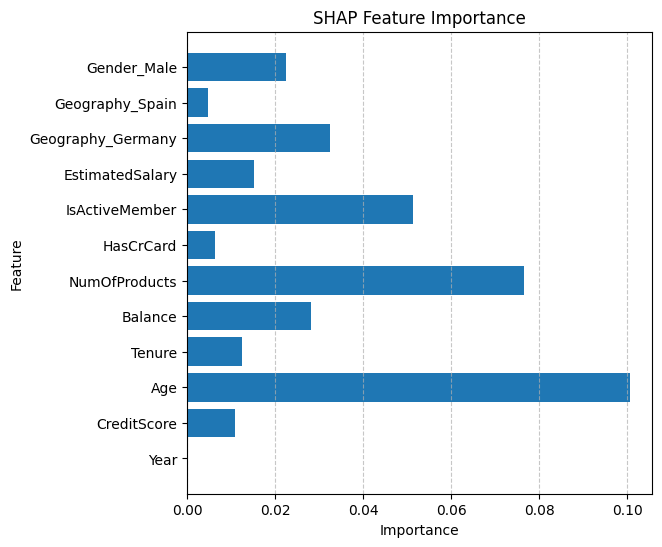

In [71]:


plt.figure(figsize=(6,6))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance")

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

### Primary Crivers of Prediciton
- #### Age:
This is the most influential feature by a significant margin (SHAP value= 0.10 approx.). This suggests that a cusotmer's life stage is the strongest predictor of their behavior in this dataset.
- #### Number of Products (NumOfProducts):
Thsi is the second most impactful variable. The way a customer diversifies their relationship with the bank/service strongly correlates with the target outcome.
- #### Active Membership (IsActiveMember):
Whether a customer is engaged and actively using the service is a high-priority indicator, ranking third in overall importance.

### Seconadry and Demographic factors
- #### Financial Indicators: Balance has a moderate impact, while EstimatedSalary and CreditScore have relatively low importance. This indicates that a customer's actual engagement and age are better predictors than their raw wealth or creditworthiness.
- #### Geographic and Gender Variance:
Germany has a notably higher impact compared to Spain, suggesting regional differences in customer behavior.
- #### Gender:
Male shows more influence than geography, implying that gender-based segments may behave differently within the model.

### Features with Minimal Impact
- #### Tenure and HasCrCard:
Surprisingly, how long customer has been with the company and whether they own a credit card have little influence on the model's final decision.
- #### Year:
This feature shows near-zero importance, suggesting that the timing within this specific dataset doesn't provide much predictive power comapred to individual customer attributes.

In [61]:
if isinstance(shap_values, list):
  shap_vals=shap_values[1]
else:
     shap_vals=shap_values
     if len(shap_vals.shape)==3:
        shap_vals=shap_vals[:,:,1]

features=X_sample.columns

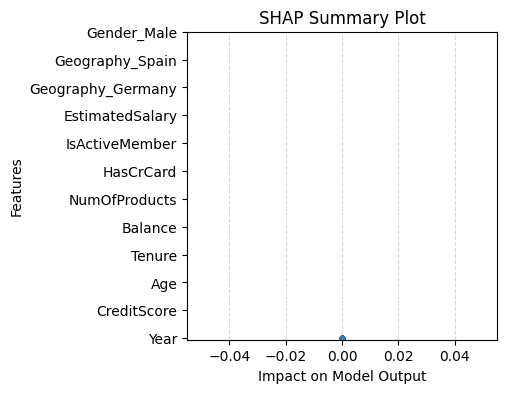

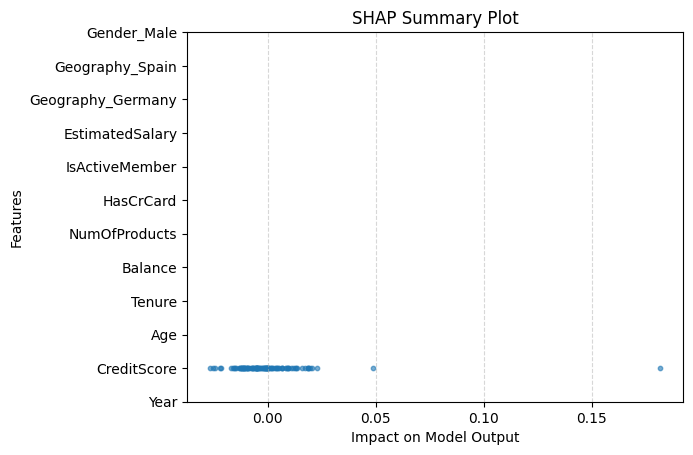

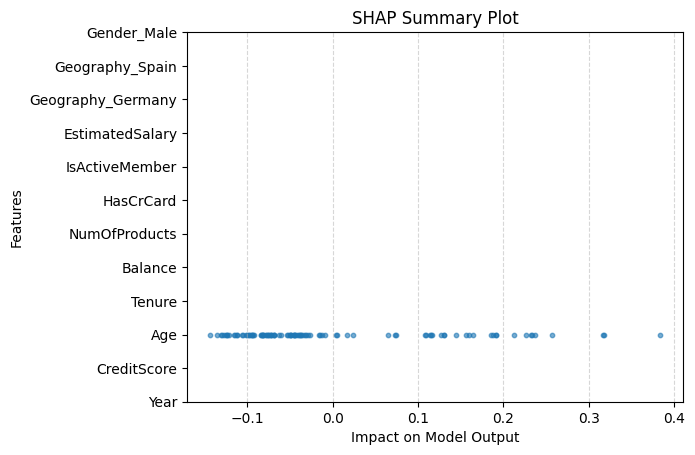

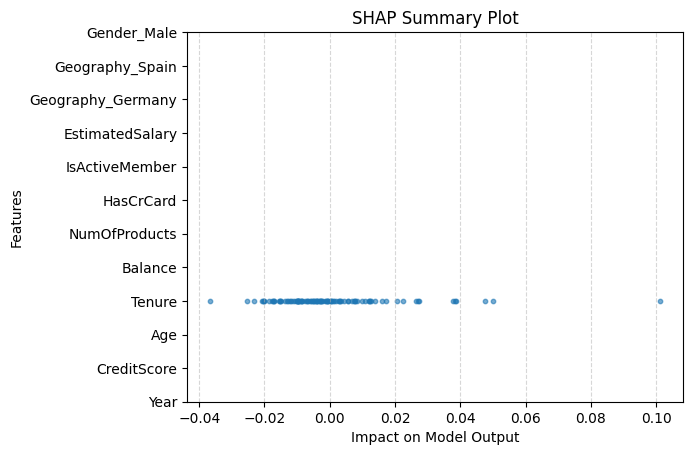

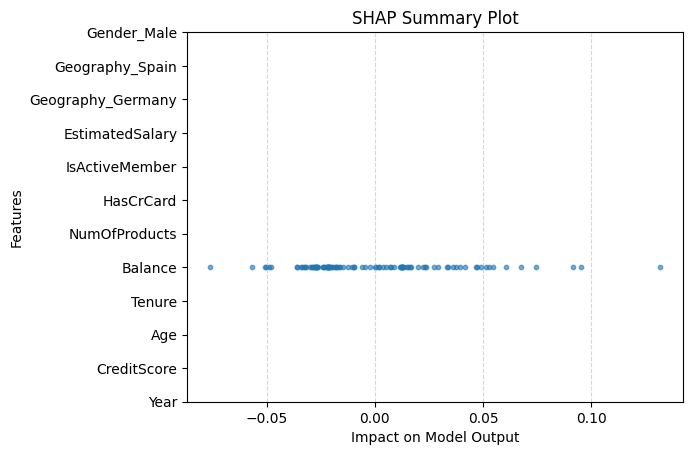

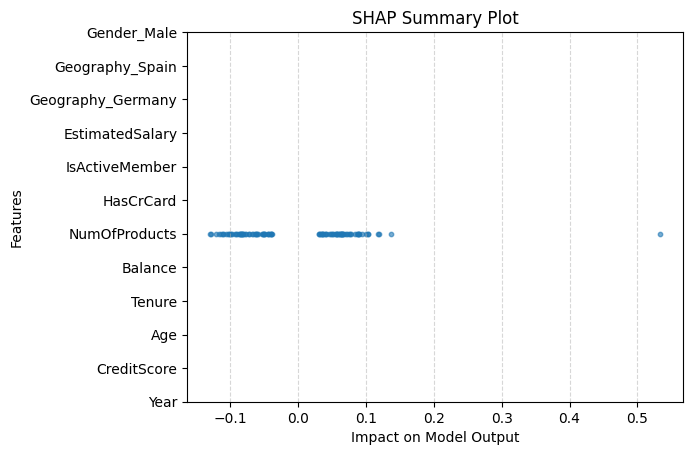

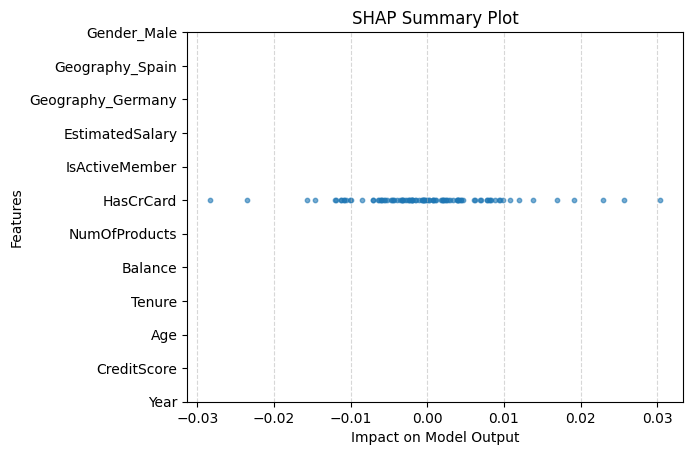

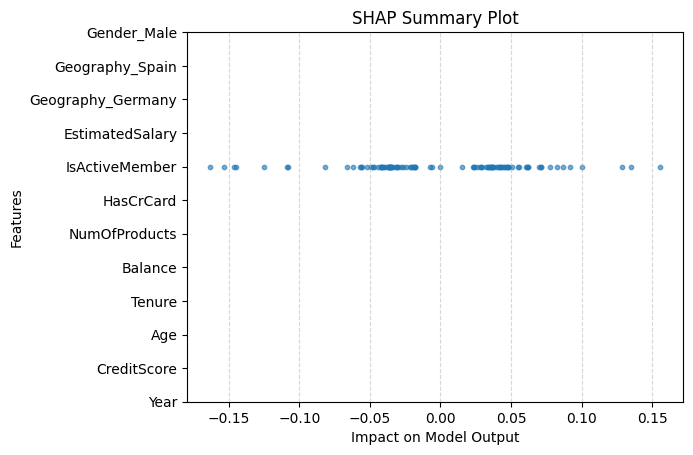

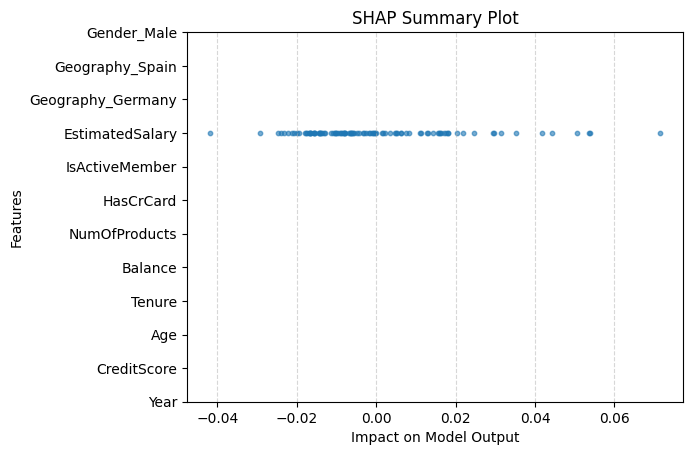

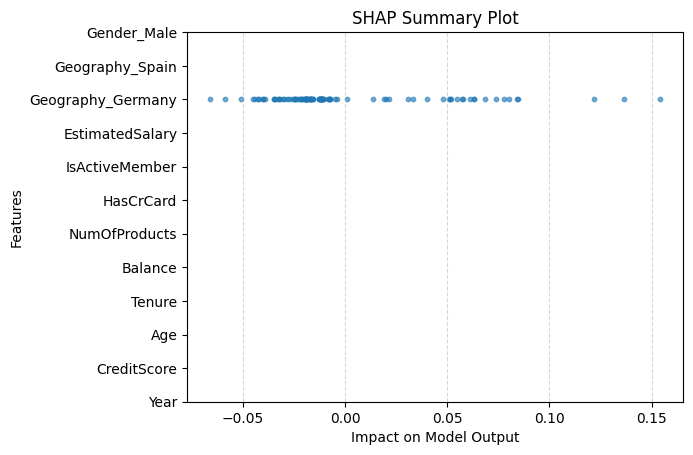

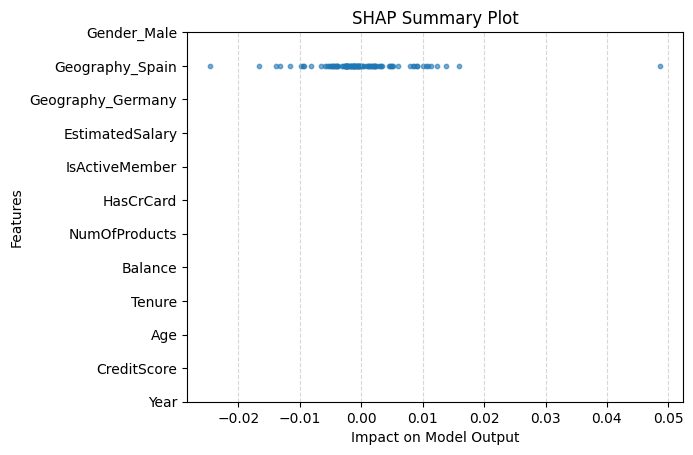

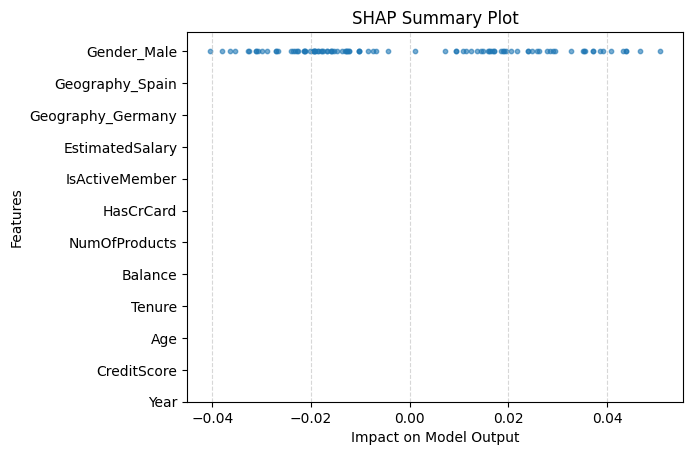

In [62]:
plt.figure(figsize=(4,4))

for i, feature in enumerate(features):
    y= np.full(shap_vals.shape[0], i)
    plt.scatter(shap_vals[:,i],y,s=10,alpha=0.6)
    plt.yticks(range(len(features)),features)
    plt.xlabel("Impact on Model Output")
    plt.ylabel("Features")
    plt.title("SHAP Summary Plot")

    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

SHAP plots illustrates the distribution of the impact each feature has on the model output. Looking at the three images, we can see the individual impacts of NumOfProducts, Balance, and Age.

#### Feature Analysis
#### NumOfProducts (High Impact)
- #### Distribution:              
This feature shows a wide spread of SHAP values, ranging from roughly -0.15 to +0.40.

- #### Insight:
It appears to be one of the most influencial features in the dataset. The significant positive SHAP values (points to the right of 0.0) suggest that for many instances, the number of products a customer has is strongly pushing the model toward a specific prediciton (likely "Churn" in this context).

#### Balance (Moderate Impact)
- #### Distribution:
Most data points are clustered around 0.0, but there is clear tail extending toward the right, reaching up to +0.18.

#### Insight:
 For the majority of customers, Balance has a neutral effect. However, for a specific subset of customers, high balances are providing a noticeable "nudge" to the model's output.

 #### Age (Low impact in this View)
 - #### Distribution: In the first image, Age is concentrated almost entirely at 0.0.
 - #### Insight: In this specific slice of data or model iteration, Age is currently showing negligible predictive power compared to the other two variables.

 #### Strategic Summary
 - #### Primary Driver: NumOfProducts is the "heavy hitter". We should investigate if there's a specific threshold (e.g., having 3+ products) that triggers a massive spikes in churn probability.

 - #### The Outlier Effect: Balance isn't a universal predictor, but it matters significantly for a small group. This suggests a non-linear relationship where only very high or very low balances change the model's behavior.


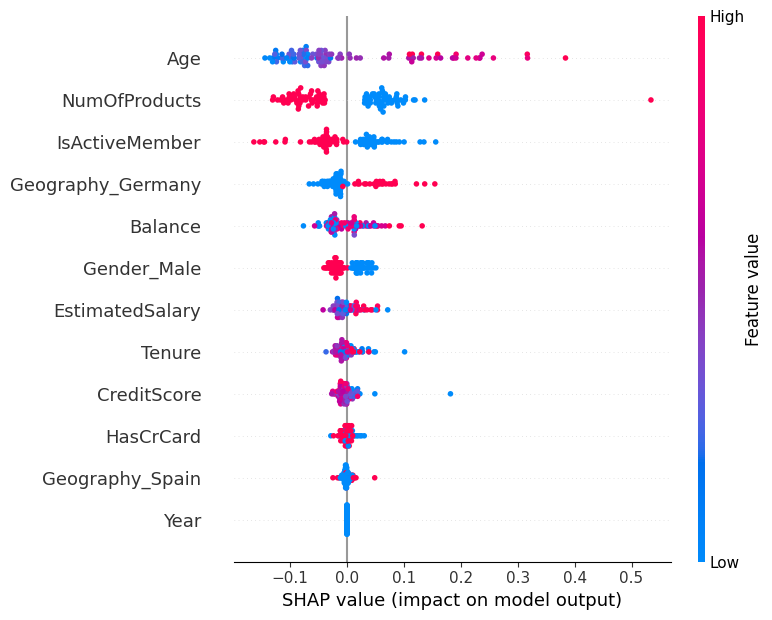

In [63]:
shap.summary_plot(shap_vals, X_sample)


### Age: The strongest Predictor
- #### Observation:
High values (red) are spread far to the right, while low values (blue) are clustered to the left.

- #### Insight:
Older customers have a significantly higher positive impact on the model output (likely increasing churn risk). This is the most impactful feature with a very clear linear-style relationship.

### NumOfProducts: The Nonlinear Interaction
- #### Observation:
This shows an interesting "flip". Lower value (blue) are on the right, and higher values (red) are on the left.

- #### Insight:
Having fewer products (blue) pushes the model toward a positive output (higher churn), whereas having more products (red) seems to act as a stabilizer or retention factor--though there are some high-value outliers on the far right that might represent customers with a "oo many products" churn risk.

### IsActiveMember: The Enagagement Factor
- #### Observation:
Blue dots (inactive) are on the right; red dots (active) are on the left.

- #### Insight:
Being an inactive member is a strong positive driver for the model outp[ut (churn). Active membership is a key protector against it.

### Geographic and Demographic Insights
- #### Geography (Germany):
High values (red, representing customers in Germany) are pushed to the right. This suggests that being based in Germany is a notable risk factor in this dataset compared to other regions.

- #### Gender (Male):
Low values (blue, representing female in binary encoding) are slightly more toward the right, while red (male) is toward the left. This implies that, in this model, being female has slightly higher impact on the churn prediction than being male.

- #### Balance:
High balances (red) show a slight pull toward the right. This aligns with the previous plot, showing that higher-wealth customers might be slightly more prone to churn or being flagged more by the model.

### Low-Impact Features (The "Noise")

The following features have SHAP values very close to 0.0, meaning they barely move the needle for the model's final decision:
- #### HasCrCard:
Whether a customer has a credit card or not has almost zero predictive power here.
- #### Tenure and EstimatedSalary:
These shows a very tight cluster aroud the center. Surprisingly, how long a customer has been with the bank or how much they earn isn't a primary driver of churn in this specific model.
- #### Year: This appears completely vertical at zero, suggesting it's a constant or a feature with no variance that shou;ld likely be dropped from training.

In [64]:
shap.initjs()

In [65]:
shap_values=explainer(X_sample,check_additivity=False)

 99%|===================| 198/200 [00:22<00:00]       

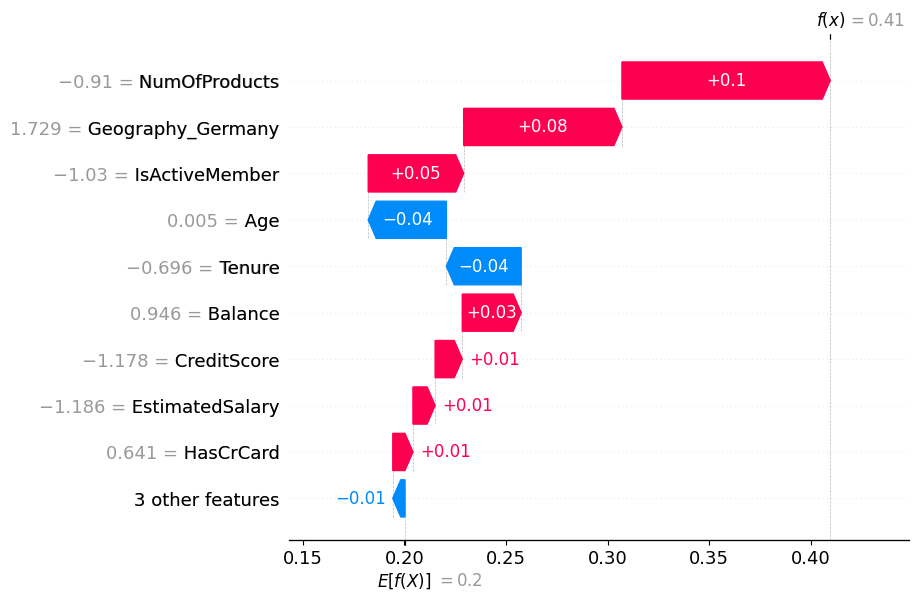

In [66]:
shap.plots.waterfall(shap_values[0,:,1])

- The Starting Point: E[f(X)]= 0.20: This baseline (expected value) is 0.2. This means that, without knowing anything about this specific customer, the model's "starting guess" based on whole dataset is a 20% churn risk.

- The "Push" Factor (Red Bars): These features increased the customer's churn risk of this specific instance:

NumOfProducts (+0.1): This is the largest single factor. Even though we saw it was important globally, for this customer, their specific number of products is the main reason their risk jumped.

Geography_Germany (+0.08): Being in Germany added another significant chunk of risk.

IsActiveMember (+0.05): Interestingly, for this person, their status as an active member pushed the risk higher.

- The "Pull" Factors (Blue Bars)
These features helped lower the risk for this specific customer:

Age (-0.04) & Tenure (-0.04): These two combined to lower the churn probability by 8%. For this specific individual, their age and how long they've been with the bank are "loyalist" signals.

- The Final Result: f(x)= 0.41: After adding and subtracting all these influences, the final probability is 41%. This customer is more than twice as likely to churn as the average customer.



In [67]:
from sklearn.inspection import PartialDependenceDisplay

In [68]:
from sklearn.inspection import partial_dependence

In [69]:
features=["Age","Balance","NumOfProducts"]

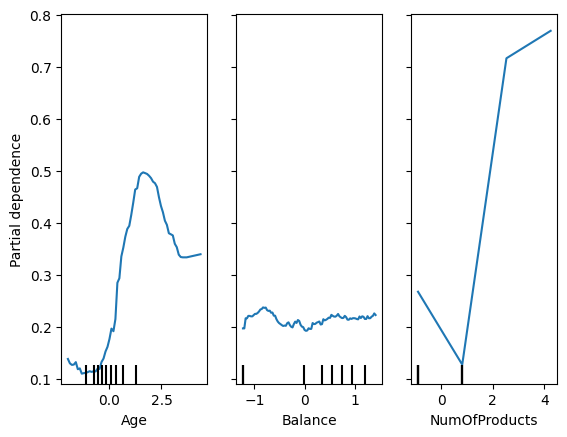

In [70]:
PartialDependenceDisplay.from_estimator(rf,X_test,features,feature_names=X.columns)
plt.show()

- Age: The "Middle-Age Risk" Peak

The  Trend: Churn risk is very low for younger customers, but it starts a steep climb around the mean (0.0 on the scaled x-axis).

The Peak: There is a distinct peak in probability (reaching 0.5) before it levels off and slightly declines.

Insights: This suggests the bank is losing a specific cohort fo middle-aged customers. This is often the segent with the highest net worth, making this a high-priority area for retention.

- Balance: The Stable Metric

The Trend: Unlike Age, the line for Balance is relatively flat across the entire range.

Insight: While "Balance" was ranked high in the importance list, this plot shows that the change in balance doesn't dramatically swing the churn probability on its own. The model likely relies on Balance in combination with other features (like Age or Products) rather than as a standalone threshold.

-NumOfProducts: The "Golden Number"

The Trend: this is the most actionable insight. There is a sharp "V" shape here.

The Sweet Spot: Risk is at its absolute lowest when a customer has exactly 1 product (scaled value near )).

The Danger Zone: Once, a customer moves to 2 or more products, the churn probability skyrockets toward 0.8.

Critical Insight: This is counter-intuitive!: Usually, more products mean more "stickiness". This pattern suggests that customers with multiple products might be experiencing poor service, high fees, or are perhaps "multi-banking" and find it easier to leave once they have several touchpoints.

